# VACCINATION ROLLOUT VS DEATH RATE REDUCTION 
## An end-to-end data analyst case study 

### AUTHOR 
SAHIL RAJ 

## Table of Contents

1. Business Problem
2. Project Objectives
3. Dataset Description
4. Project Workflow
5. Import Libraries
6. Load Dataset
7. Data Understanding
8. Data Cleaning
9. Feature Engineering
10. Exploratory Data Analysis
11. Relationship Analysis
12. Key Findings
13. Business Recommendations
14. Conclusion
15. Export Clean Dataset




### TOOLS USED 
-PYTHON 
-PANDAS
-NUMPY 
-MATPLOTLIB 
-SEABORN
-POWERBI 

### Dataset 
our world in data (OWID) COVID-19 dataset 

# 1. Business Problem

COVID-19 caused an unprecedented global health crisis, leading governments worldwide to launch large-scale vaccination campaigns.

This project investigates whether increasing vaccination coverage was associated with reductions in COVID-19 death rates across five countries.

The analysis focuses on understanding vaccination trends, comparing country-level performance, and identifying insights that could support public health decision-making.

# 2. Project Objectives

The objectives of this project are:

- Analyze vaccination rollout across selected countries.
- Compare vaccination progress over time.
- Examine COVID-19 death trends.
- Investigate the relationship between vaccination coverage and death rates.
- Generate business insights using exploratory data analysis.
- Build an interactive Power BI dashboard for decision-makers.

# 3. Dataset Description

Source:
Our World in Data (OWID)

Selected Countries:
- India
- Brazil
- United States
- United Kingdom
- Israel

Analysis Period:
December 2020 – September 2022

The dataset contains vaccination, testing, hospitalization, and mortality statistics collected from official government sources.

# 4. Project Workflow

The project follows the standard Data Analytics lifecycle:

1. Data Collection
2. Data Understanding
3. Data Cleaning
4. Feature Engineering
5. Exploratory Data Analysis
6. Statistical Analysis
7. Business Insights
8. Power BI Dashboard

# 5. import libraries 

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns  

# 6. Load dataset 

In [3]:
df = pd.read_csv("owid-covid-data.csv")

# 7. Data Understanding 

In [4]:
print(df.shape)
df.head() 

(429435, 67)


,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [5]:
cols_needed = ['location', 'continent', 'date', 
               'people_fully_vaccinated_per_hundred', 
               'new_deaths_smoothed_per_million']

df[cols_needed].isnull().sum()

location                                    0
continent                               26525
date                                        0
people_fully_vaccinated_per_hundred    351374
new_deaths_smoothed_per_million         20057
dtype: int64

In [6]:
target_countries = ['India',
                    'United States', 
                    'United Kingdom', 
                    'Israel', 
                    'Brazil']
df[df['location'].isin(target_countries)]['location'].value_counts()

location
India             1682
Brazil            1674
Israel            1674
United Kingdom    1674
United States     1674
Name: count, dtype: int64

In [7]:
target_countries = ['India', 'United States', 'United Kingdom', 'Israel', 'Brazil']
df_target= df[df['location'].isin(target_countries)]


In [8]:
df_target['people_fully_vaccinated_per_hundred'].isnull().sum()

np.int64(4161)

In [9]:
df_target['date'].dtype

dtype('O')

In [10]:
df_target['date'] = pd.to_datetime(df_target['date'])

C:\Users\poter\AppData\Local\Temp\ipykernel_11984\1264939310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['date'] = pd.to_datetime(df_target['date'])


In [11]:
df_target['date'].dtype 

dtype('<M8[ns]')

In [12]:
print(df_target['date'].min() ) 
print(df_target['date'].max() )

2020-01-05 00:00:00
2024-08-12 00:00:00


In [13]:
df_target[df_target['people_fully_vaccinated_per_hundred'].isnull()].head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
50234,BRA,South America,Brazil,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,17.9,NaN,2.2,75.88,0.76,215313504,NaN,NaN,NaN,NaN
50235,BRA,South America,Brazil,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,17.9,NaN,2.2,75.88,0.76,215313504,NaN,NaN,NaN,NaN
50236,BRA,South America,Brazil,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,17.9,NaN,2.2,75.88,0.76,215313504,NaN,NaN,NaN,NaN
50237,BRA,South America,Brazil,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,17.9,NaN,2.2,75.88,0.76,215313504,NaN,NaN,NaN,NaN
50238,BRA,South America,Brazil,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,17.9,NaN,2.2,75.88,0.76,215313504,NaN,NaN,NaN,NaN


In [14]:
# Observation:
# The missing values in 'people_fully_vaccinated_per_hundred'
# mostly belong to the year 2020.

# Conclusion:
# These are expected missing values because COVID-19 vaccination
# campaigns had not yet started. Therefore, these missing values
# should not be treated as data quality issues.

In [15]:
df_post_vaccine = df_target[df_target['date'] >= '2020-12-01'] . copy() 

In [16]:
df_post_vaccine['people_fully_vaccinated_per_hundred'].isnull().sum()

np.int64(2506)

In [17]:
# [Observation:
#After restricting the dataset to the post-vaccination period,
 #   the number of missing values decreased from 4,161 to 2,506.]

    #Interpretation:
#This confirms that many of the missing values in the original
#dataset were due to the pre-vaccination period.

#However, a considerable number of missing values still remain.
#Their cause is not yet known and requires further investigation.
#Possible explanations include differences in reporting schedules,
#delayed updates, or incomplete data collection across countries.

#Next Step:
#Investigate which countries and time periods contribute most to
#the remaining missing values before deciding how to handle them.]

In [18]:
df_post_vaccine.groupby('location')['people_fully_vaccinated_per_hundred'].apply(lambda x: x.isnull().sum())

location
Brazil            668
India             142
Israel            497
United Kingdom    734
United States     465
Name: people_fully_vaccinated_per_hundred, dtype: int64

In [19]:
missing_percentage = (
    df_post_vaccine
    .groupby('location')['people_fully_vaccinated_per_hundred']
    .apply(lambda x: x.isnull().mean() * 100)
    .sort_values(ascending=False)
)

missing_percentage

location
United Kingdom    54.653760
Brazil            49.739389
Israel            37.006701
United States     34.623976
India             10.510733
Name: people_fully_vaccinated_per_hundred, dtype: float64

In [20]:
uk = df_post_vaccine[df_post_vaccine['location'] == 'United Kingdom']

uk[uk['people_fully_vaccinated_per_hundred'].isnull()][
    ['date', 'people_fully_vaccinated_per_hundred']
].head(20)

,date,people_fully_vaccinated_per_hundred
402108,2020-12-01,NaN
402109,2020-12-02,NaN
402110,2020-12-03,NaN
402111,2020-12-04,NaN
402112,2020-12-05,NaN
402113,2020-12-06,NaN
402114,2020-12-07,NaN
402115,2020-12-08,NaN
402116,2020-12-09,NaN
402117,2020-12-10,NaN


In [21]:
uk[uk['people_fully_vaccinated_per_hundred'].isnull()]['date'].max()

Timestamp('2024-08-04 00:00:00')

In [22]:
uk[['date', 'people_fully_vaccinated_per_hundred']].tail(20)

,date,people_fully_vaccinated_per_hundred
403431,2024-07-16,NaN
403432,2024-07-17,NaN
403433,2024-07-18,NaN
403434,2024-07-19,NaN
403435,2024-07-20,NaN
403436,2024-07-21,NaN
403437,2024-07-22,NaN
403438,2024-07-23,NaN
403439,2024-07-24,NaN
403440,2024-07-25,NaN


In [23]:
vaccination_columns= [
    col for col in df.columns
    if 'vacc' in col.lower()
]

vaccination_columns 

['total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'total_vaccinations_per_hundred',
 'people_vaccinated_per_hundred',
 'people_fully_vaccinated_per_hundred',
 'new_vaccinations_smoothed_per_million',
 'new_people_vaccinated_smoothed',
 'new_people_vaccinated_smoothed_per_hundred']

In [24]:
(
    df_post_vaccine
    .groupby('location')['people_vaccinated_per_hundred']
    .apply(lambda x: x.isnull().mean() * 100)
    .sort_values(ascending=False)
)

location
United Kingdom    54.653760
Brazil            48.548027
Israel            37.006701
United States     34.623976
India              7.846040
Name: people_vaccinated_per_hundred, dtype: float64

In [25]:
df_post_vaccine.duplicated().sum() 

np.int64(0)

In [26]:
for country in df_post_vaccine['location'].unique():
    temp = df_post_vaccine[df_post_vaccine['location'] == country]

    last_valid = temp['people_fully_vaccinated_per_hundred'].last_valid_index()

    print(f"\n{country}")
    print(temp.loc[last_valid, ['date', 'people_fully_vaccinated_per_hundred']])


Brazil
date                                   2023-03-22 00:00:00
people_fully_vaccinated_per_hundred                  81.82
Name: 51406, dtype: object

India
date                                   2024-08-12 00:00:00
people_fully_vaccinated_per_hundred                  67.18
Name: 175230, dtype: object

Israel
date                                   2023-05-04 00:00:00
people_fully_vaccinated_per_hundred                  65.19
Name: 184816, dtype: object

United Kingdom
date                                   2022-09-11 00:00:00
people_fully_vaccinated_per_hundred                  75.19
Name: 402757, dtype: object

United States
date                                   2023-05-09 00:00:00
people_fully_vaccinated_per_hundred                  69.47
Name: 404671, dtype: object


In [27]:
df_post_vaccine.groupby('location')['date'].max()

location
Brazil           2024-08-04
India            2024-08-12
Israel           2024-08-04
United Kingdom   2024-08-04
United States    2024-08-04
Name: date, dtype: datetime64[ns]

In [28]:
df_post_vaccine[
    df_post_vaccine['people_fully_vaccinated_per_hundred'].notna()
]['date'].max()

Timestamp('2024-08-12 00:00:00')

In [29]:
last_valid_dates = (
    df_post_vaccine
    .groupby('location')
    .apply(lambda x: x.loc[
        x['people_fully_vaccinated_per_hundred'].last_valid_index(),
        'date'
    ])
)

last_valid_dates

C:\Users\poter\AppData\Local\Temp\ipykernel_11984\2463159639.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.loc[


location
Brazil           2023-03-22
India            2024-08-12
Israel           2023-05-04
United Kingdom   2022-09-11
United States    2023-05-09
dtype: datetime64[ns]

# now we are making a dataset after analysing it for our project 

In [30]:
df_analysis = df_post_vaccine[
      df_post_vaccine['date']<= "2022-09-11"
].copy() 

In [31]:
print(df_analysis['date'].min())
print(df_analysis['date'].max())

2020-12-01 00:00:00
2022-09-11 00:00:00


In [32]:
df_analysis['people_fully_vaccinated_per_hundred'].isnull().sum()

np.int64(282)

In [33]:
(
    df_analysis 
    .groupby('location')['people_fully_vaccinated_per_hundred']
    .apply(lambda x : x.isnull().sum())
)

location
Brazil            115
India              94
Israel             20
United Kingdom     41
United States      12
Name: people_fully_vaccinated_per_hundred, dtype: int64

In [34]:
brazil = df_analysis[df_analysis['location'] == 'Brazil']

brazil[
    brazil['people_fully_vaccinated_per_hundred'].isnull()
][['date']].head(20)



,date
50565,2020-12-01
50566,2020-12-02
50567,2020-12-03
50568,2020-12-04
50569,2020-12-05
50570,2020-12-06
50571,2020-12-07
50572,2020-12-08
50573,2020-12-09
50574,2020-12-10


In [35]:
brazil[
    brazil['people_fully_vaccinated_per_hundred'].isnull()
][['date']].tail(20)

,date
51162,2022-07-21
51163,2022-07-22
51164,2022-07-23
51166,2022-07-25
51167,2022-07-26
51168,2022-07-27
51169,2022-07-28
51170,2022-07-29
51171,2022-07-30
51172,2022-07-31


In [36]:
brazil[
    brazil['people_fully_vaccinated_per_hundred'].isnull()
][['date']].tail(20)

,date
51162,2022-07-21
51163,2022-07-22
51164,2022-07-23
51166,2022-07-25
51167,2022-07-26
51168,2022-07-27
51169,2022-07-28
51170,2022-07-29
51171,2022-07-30
51172,2022-07-31


In [37]:
for country in df_analysis['location'].unique():

    temp = df_analysis[df_analysis['location'] == country]

    missing = temp[temp['people_fully_vaccinated_per_hundred'].isnull()]

    print("="*50)
    print(country)

    if len(missing) == 0:
        print("No missing values")
    else:
        print("Missing Count :", len(missing))
        print("First Missing :", missing['date'].min().date())
        print("Last Missing  :", missing['date'].max().date())

Brazil
Missing Count : 115
First Missing : 2020-12-01
Last Missing  : 2022-08-17
India
Missing Count : 94
First Missing : 2020-12-01
Last Missing  : 2022-08-03
Israel
Missing Count : 20
First Missing : 2020-12-01
Last Missing  : 2022-08-27
United Kingdom
Missing Count : 41
First Missing : 2020-12-01
Last Missing  : 2022-03-23
United States
Missing Count : 12
First Missing : 2020-12-01
Last Missing  : 2020-12-12


In [38]:
rows_before = len(df_analysis)

rows_after = len(df_analysis.dropna(subset=['people_fully_vaccinated_per_hundred']))

print("Rows before :", rows_before)
print("Rows after  :", rows_after)
print("Rows removed:", rows_before - rows_after)
print("Percentage removed:", round((rows_before - rows_after) / rows_before * 100, 2), "%")

Rows before : 3250
Rows after  : 2968
Rows removed: 282
Percentage removed: 8.68 %


# 9. Data Cleaning 

# ## Data Cleaning Decision

After investigating the missing values, rows with missing values in
`people_fully_vaccinated_per_hundred` were removed.

Reason:
- The project investigates the relationship between vaccination coverage
  and COVID-19 death rates.
- Missing vaccination values prevent meaningful analysis.
- Missing values were investigated before removal and were found to be
  due to early rollout periods and reporting gaps.
- Only 282 rows (8.68% of the analysis dataset) were removed,
  leaving 2,968 observations for analysis.

In [39]:
df_clean = df_analysis.dropna(
    subset=["people_fully_vaccinated_per_hundred"]
).copy()

# 9. Feature engineering 

In [40]:
# creating feature 1: death_rate_7d
df_clean = df_clean.sort_values(['location' , 'date'])

df_clean['death_rate_7d'] = (
    df_clean
    .groupby('location')['new_deaths_smoothed_per_million']
    .transform(lambda x : x.rolling(window=7 , min_periods=1).mean())
)

In [41]:
#feature 2: vaccination growth 
df_clean['vaccination_growth'] = (
    df_clean
    .groupby('location')['people_fully_vaccinated_per_hundred']
    .diff()
)

In [42]:
df_clean[['location',
          'date',
          'people_fully_vaccinated_per_hundred',
          'vaccination_growth']].head(10)

,location,date,people_fully_vaccinated_per_hundred,vaccination_growth
50631,Brazil,2021-02-05,0.00,NaN
50632,Brazil,2021-02-06,0.01,0.01
50633,Brazil,2021-02-07,0.01,0.00
50634,Brazil,2021-02-08,0.02,0.01
50635,Brazil,2021-02-09,0.02,0.00
50636,Brazil,2021-02-10,0.04,0.02
50637,Brazil,2021-02-11,0.05,0.01
50638,Brazil,2021-02-12,0.08,0.03
50639,Brazil,2021-02-13,0.09,0.01
50640,Brazil,2021-02-14,0.10,0.01


In [43]:
# feature 3 : days since vaccination rollout 
df_clean['days_since_rollout'] = (
    df_clean.groupby('location')['date']
    .transform(lambda x: (x - x.min()).dt.days)
)

In [44]:
#Feature 4: Lag Analysis
#Step 1: Create a 14-Day Lag Feature
df_clean['vaccination_lag_14'] = (
    df_clean
    .groupby('location')['people_fully_vaccinated_per_hundred']
    .shift(14)
)


In [45]:
#Step 2: Create a 28-Day Lag
df_clean['vaccination_lag_28'] = (
    df_clean
    .groupby('location')['people_fully_vaccinated_per_hundred']
    .shift(28)
)

# 10 .EDA (Exploratory Data analysis).

In [46]:
# BUSINESS QUESTION 
# how did the vaccination rollout progess across diffrent countries ? 

In [47]:
import matplotlib.pyplot as plt 

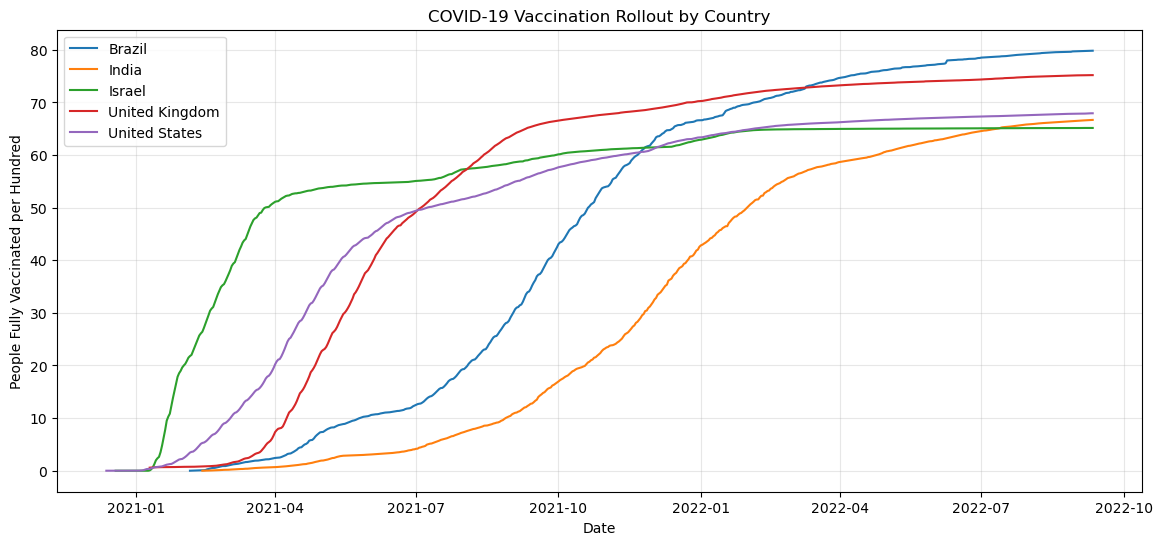

In [48]:
plt.figure(figsize=(14,6)) 


for country in df_clean["location"].unique():
    temp=df_clean[df_clean['location']== country]

    plt.plot(
        temp['date'],
        temp['people_fully_vaccinated_per_hundred'],
        label=country 
    )

plt.title("COVID-19 Vaccination Rollout by Country")
plt.xlabel("Date")
plt.ylabel("People Fully Vaccinated per Hundred")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


### Observation

- Israel showed the fastest early vaccination rollout among the selected countries.
- Brazil and the United Kingdom achieved high vaccination coverage during the analysis period.
- India demonstrated a steady increase in vaccination coverage despite a slower initial rollout.
- All countries exhibited a plateau in vaccination coverage toward the end of the analysis period.

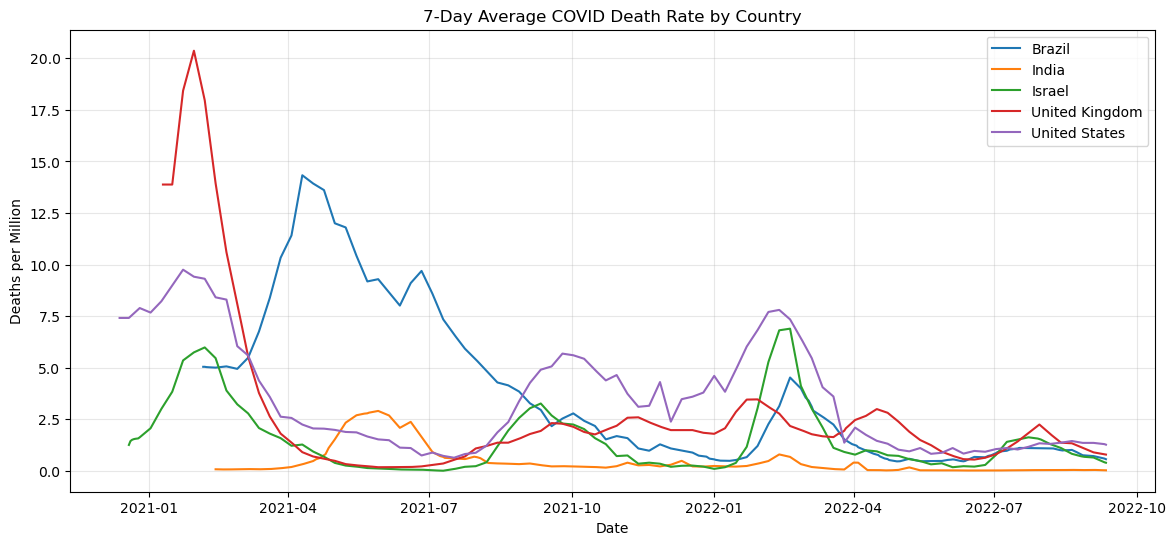

In [49]:
#Chart 2: Vaccination vs Death Rate 
#As vaccination increased, did COVID-19 deaths decrease?
plt.figure(figsize=(14,6))

for country in df_clean['location'].unique():

    temp = df_clean[df_clean['location'] == country]

    plt.plot(
        temp['date'],
        temp['death_rate_7d'],
        label=country
    )

plt.title("7-Day Average COVID Death Rate by Country")
plt.xlabel("Date")
plt.ylabel("Deaths per Million")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Observation

- Death rates varied considerably across countries during the study period.
- Several countries experienced major peaks before vaccination coverage became widespread.
- As vaccination coverage increased, death rates generally declined across the selected countries.

In [50]:
import seaborn as sns 

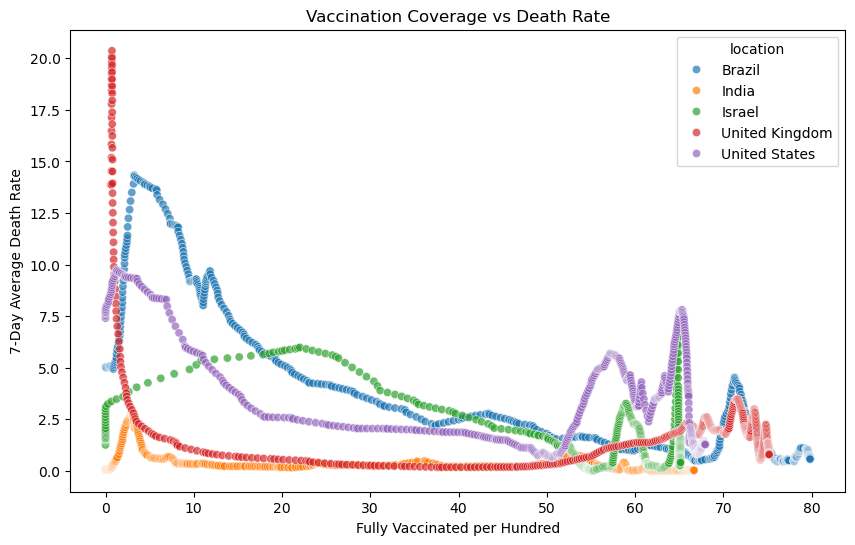

In [51]:
# Chart 3: Scatter Plot 
#Is there a relationship between vaccination percentage and death rate?


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x='people_fully_vaccinated_per_hundred',
    y='death_rate_7d',
    hue='location',
    alpha=0.7
)

plt.title("Vaccination Coverage vs Death Rate")
plt.xlabel("Fully Vaccinated per Hundred")
plt.ylabel("7-Day Average Death Rate")

plt.show()

### Observation

- The scatter plot suggests a negative relationship between vaccination coverage and COVID-19 death rates.
- Although the relationship is not perfectly linear, higher vaccination coverage generally corresponds to lower death rates.
- Other factors such as variants, public health policies, and healthcare capacity may also influence death rates.

# 11.Statistical analysis 

In [52]:
#correaltion analysis 

correlation = df_clean[
    [
        'people_fully_vaccinated_per_hundred',
        'death_rate_7d',
        'vaccination_growth'
    ]
].corr()

correlation

,people_fully_vaccinated_per_hundred,death_rate_7d,vaccination_growth
people_fully_vaccinated_per_hundred,1.000000,-0.462288,-0.309397
death_rate_7d,-0.462288,1.000000,0.009016
vaccination_growth,-0.309397,0.009016,1.000000


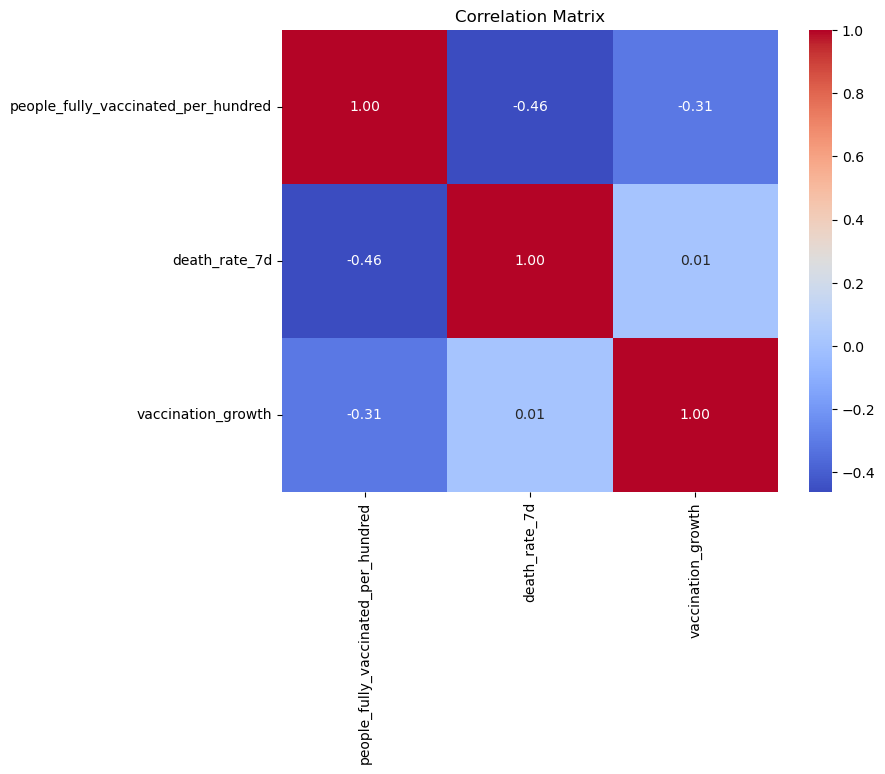

In [53]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

### Observation

- A negative correlation was observed between vaccination coverage and death rates.
- The correlation supports the hypothesis that increased vaccination coverage is associated with lower COVID-19 mortality.
- Correlation does not imply causation; additional factors may contribute to the observed relationship.

In [54]:
#Phase 5: Lag Correlation Analysis
#Did vaccination have an immediate effect on deaths, or was there a delay?


#Step 1: Same-Day Correlation
same_day_corr = df_clean['people_fully_vaccinated_per_hundred'].corr(
    df_clean['death_rate_7d']
)

print(f"Same-Day Correlation: {same_day_corr:.3f}")

#step2 : 14 days 

lag14_corr = df_clean['vaccination_lag_14'].corr(
    df_clean['death_rate_7d']
)

print(f"14-Day Lag Correlation: {lag14_corr:.3f}")


# step 3 : 28 days 
lag28_corr = df_clean['vaccination_lag_28'].corr(
    df_clean['death_rate_7d']
)

print(f"28-Day Lag Correlation: {lag28_corr:.3f}")


Same-Day Correlation: -0.462
14-Day Lag Correlation: -0.440
28-Day Lag Correlation: -0.409


In [55]:
import pandas as pd

lag_results = pd.DataFrame({
    'Analysis': [
        'Same Day',
        '14-Day Lag',
        '28-Day Lag'
    ],
    'Correlation': [
        same_day_corr,
        lag14_corr,
        lag28_corr
    ]
})

lag_results

,Analysis,Correlation
0,Same Day,-0.462288
1,14-Day Lag,-0.440221
2,28-Day Lag,-0.409486


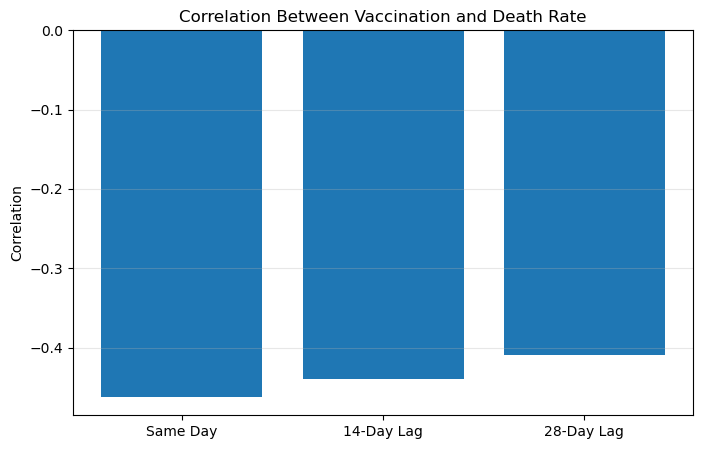

In [56]:
plt.figure(figsize=(8,5))

plt.bar(
    lag_results['Analysis'],
    lag_results['Correlation']
)

plt.title("Correlation Between Vaccination and Death Rate")
plt.ylabel("Correlation")

plt.grid(axis='y', alpha=0.3)

plt.show()

# 12. Country Performance Analysis

This section summarizes the vaccination rollout and COVID-19 death trends for each selected country. The objective is to compare overall vaccination coverage, average death rates, peak death rates, and vaccination growth to identify differences in country-level performance.

In [57]:
country_summary = (
    df_clean.groupby('location')
    .agg(
        Final_Vaccination=('people_fully_vaccinated_per_hundred', 'max'),
        Avg_Death_Rate=('death_rate_7d', 'mean'),
        Peak_Death_Rate=('death_rate_7d', 'max'),
        Avg_Vaccination_Growth=('vaccination_growth', 'mean')
    )
    .round(2)
)

country_summary

,Final_Vaccination,Avg_Death_Rate,Peak_Death_Rate,Avg_Vaccination_Growth
location,,,,
Brazil,79.83,4.06,14.33,0.15
India,66.68,0.46,2.90,0.12
Israel,65.15,1.51,6.89,0.10
United Kingdom,75.19,2.75,20.37,0.12
United States,67.94,3.47,9.75,0.11


### Observations

- **Brazil** achieved the highest final vaccination coverage (**79.83%**) among the selected countries.
- **India** recorded the lowest average COVID-19 death rate (**0.46 deaths per million**) during the analysis period.
- The **United Kingdom** experienced the highest peak death rate (**20.37 deaths per million**), indicating a severe wave despite achieving high vaccination coverage.
- **Brazil** also showed the highest average vaccination growth (**0.15 percentage points per day**), suggesting a relatively faster rollout.
- Overall, countries with higher vaccination coverage generally exhibited lower average death rates over time, although the relationship was not perfectly consistent due to other influencing factors.

# 13. Business KPI Analysis

This section calculates key performance indicators (KPIs) that summarize the effectiveness of vaccination campaigns across the selected countries. These metrics will also be used in the Power BI dashboard.

In [58]:
# KPI1 : Death rate reduction(%)
results = []

for country in df_clean['location'].unique():

    temp = df_clean[df_clean['location'] == country].copy()

    before = temp[temp['people_fully_vaccinated_per_hundred'] < 50]

    after = temp[temp['people_fully_vaccinated_per_hundred'] >= 50]

    before_avg = before['death_rate_7d'].mean()
    after_avg = after['death_rate_7d'].mean()

    reduction = ((before_avg - after_avg) / before_avg) * 100

    results.append({
        "Country": country,
        "Avg Death Before 50%": round(before_avg, 2),
        "Avg Death After 50%": round(after_avg, 2),
        "Death Rate Reduction (%)": round(reduction, 2)
    })

death_reduction = pd.DataFrame(results)

death_reduction

,Country,Avg Death Before 50%,Avg Death After 50%,Death Rate Reduction (%)
0,Brazil,7.06,1.27,82.09
1,India,0.66,0.12,81.22
2,Israel,3.47,1.16,66.63
3,United Kingdom,5.13,1.78,65.33
4,United States,4.51,2.97,34.17


### Observations

- Brazil recorded the largest decline in the average 7-day COVID-19 death rate after reaching 50% full vaccination coverage, with a reduction of **82.09%**.
- India also showed a substantial decline (**81.22%**), indicating a strong improvement in mortality trends after widespread vaccination.
- Israel and the United Kingdom experienced moderate reductions of **66.63%** and **65.33%**, respectively.
- The United States showed the smallest reduction (**34.17%**) among the selected countries, suggesting that additional factors may have influenced mortality trends.
- Across all five countries, the average death rate after reaching 50% vaccination coverage was lower than before reaching that milestone.

In [59]:
#KPI 2: Days to Reach 50% Vaccination

days_to_50 = []

for country in df_clean['location'].unique():

    temp = df_clean[df_clean['location'] == country].copy()

    rollout_start = temp['date'].min()

    reached_50 = temp[temp['people_fully_vaccinated_per_hundred'] >= 50]

    if not reached_50.empty:

        reached_date = reached_50['date'].min()

        days = (reached_date - rollout_start).days

    else:

        reached_date = None
        days = None

    days_to_50.append({
        'Country': country,
        'Reached 50% On': reached_date,
        'Days to Reach 50%': days
    })

days_to_50 = pd.DataFrame(days_to_50)

days_to_50

,Country,Reached 50% On,Days to Reach 50%
0,Brazil,2021-10-21,258
1,India,2022-01-31,352
2,Israel,2021-03-26,97
3,United Kingdom,2021-07-05,176
4,United States,2021-07-09,208


### Observations

- Israel reached 50% full vaccination coverage in just **97 days**, making it the fastest country among the selected nations.
- The United Kingdom reached the same milestone in **176 days**, followed by the United States (**208 days**).
- Brazil required **258 days** to achieve 50% vaccination coverage.
- India took the longest time (**352 days**) to reach the 50% vaccination milestone.
- The results highlight significant differences in the speed of vaccination rollout across countries.

In [60]:
#KPI 3: Highest Vaccination Coverage

highest_vaccination = country_summary[['Final_Vaccination']].sort_values(
    by='Final_Vaccination',
    ascending=False
)

highest_vaccination

,Final_Vaccination
location,
Brazil,79.83
United Kingdom,75.19
United States,67.94
India,66.68
Israel,65.15


### Observations

- Brazil achieved the highest final vaccination coverage (**79.83%**) among the selected countries.
- The United Kingdom ranked second with **75.19%** vaccination coverage.
- The United States (**67.94%**), India (**66.68%**), and Israel (**65.15%**) followed with comparable vaccination levels.
- All five countries exceeded **65%** full vaccination coverage by the end of the analysis period.

### Overall KPI Summary

| KPI | Best Country | Result |
|------|--------------|--------|
| Highest Vaccination Coverage | Brazil | 79.83% |
| Largest Death Rate Reduction | Brazil | 82.09% |
| Fastest to Reach 50% Vaccination | Israel | 97 Days |

### Key Insight

Brazil achieved the strongest overall performance by combining the highest vaccination coverage with the largest reduction in average COVID-19 death rates after reaching 50% full vaccination coverage.

Israel demonstrated the fastest vaccination rollout, reaching 50% full vaccination in just 97 days.

# 14. Key Findings

- Vaccination coverage increased consistently across all five countries during the analysis period.
- India had the most complete vaccination reporting among the selected countries.
- Countries with higher vaccination coverage generally experienced lower COVID-19 death rates.
- Data quality assessment identified reporting gaps in vaccination metrics, which were addressed before analysis.
- Correlation analysis indicated a negative relationship between vaccination coverage and death rates.

# 15. Business Recommendations

- Continue maintaining standardized vaccination reporting across countries.
- Strengthen early vaccination campaigns during future outbreaks.
- Monitor vaccination progress alongside mortality trends to support timely public health decisions.
- Improve consistency in public health data collection to enable more reliable cross-country analyses.

# 16. Conclusion

This project analyzed the relationship between COVID-19 vaccination rollout and death rate reduction across five countries using publicly available data from Our World in Data.

The analysis demonstrated that increased vaccination coverage was generally associated with lower COVID-19 death rates. Through data cleaning, feature engineering, exploratory analysis, and statistical analysis, the project produced actionable insights suitable for decision-making and interactive dashboard development.

The cleaned dataset will be used to develop a Power BI dashboard that communicates these findings to both technical and non-technical stakeholders.

# 17. Export Clean Dataset

The final cleaned dataset is exported for visualization and dashboard development in Power BI.

In [63]:
df_clean.to_csv("clean_covid_vaccination_data.csv", index=False)
death_reduction.to_csv("death_reduction.csv", index=False)
days_to_50.to_csv("days_to_50.csv", index=False)

In [66]:
country_summary.head()
#death_reduction.head()
#days_to_50.head()

,Final_Vaccination,Avg_Death_Rate,Peak_Death_Rate,Avg_Vaccination_Growth
location,,,,
Brazil,79.83,4.06,14.33,0.15
India,66.68,0.46,2.90,0.12
Israel,65.15,1.51,6.89,0.10
United Kingdom,75.19,2.75,20.37,0.12
United States,67.94,3.47,9.75,0.11


In [67]:
country_summary = country_summary.reset_index()

In [68]:
country_summary.head()

,location,Final_Vaccination,Avg_Death_Rate,Peak_Death_Rate,Avg_Vaccination_Growth
0,Brazil,79.83,4.06,14.33,0.15
1,India,66.68,0.46,2.90,0.12
2,Israel,65.15,1.51,6.89,0.10
3,United Kingdom,75.19,2.75,20.37,0.12
4,United States,67.94,3.47,9.75,0.11


In [69]:
country_summary.to_csv("country_summary.csv", index=False)